# Лабораторная работа №4. Синтез КИХ-фильтров.
Лаборатория цифровой обработки сигналов, МФТИ

Вариант определяется первой буквой фамилии. Задача 4.1 выполняется с использованием цифрового осциллографа. 

|                  Вариант                                                       |      А |      Б |      В |      Г |      Д |    Е,Ё |    Ж,З |   И, Й |      К |      Л |      М |      Н |      О |      П |      Р |      С |    Т,У |    Ф,Х |   Ц,Ч, Ш,Щ |   Ы,Э,Ю,Я |
|:------------------------------------------------------------------------|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-------:|-----------:|----------:|
| Частота  дискретизации $f_s$, кГц.                                      | 100    | 100    | 100    | 100    | 100    | 100    | 100    | 100    | 100    | 100    | 100    | 100    | 100    | 100    | 100    | 100    | 100    | 100    |     100    |    100    |
| Граничная частота полосы пропускания $f_1$, кГц.                        |  18    |  29    |  19    |  25    |  27    |  34    |  22    |  28    |  28    |  33    |  25    |  22    |  23    |  17    |  15    |  30    |  33    |  26    |      25    |     25    |
| Граничная частота полосы задерживания $f_2$, кГц.                       |  22    |  33    |  23    |  29    |  31    |  38    |  26    |  32    |  32    |  37    |  29    |  26    |  27    |  21    |  19    |  34    |  37    |  30    |      29    |     29    |
| Максимально допустимое отклонение АЧХ в полосе пропускания $\delta_1$.  |   0.09 |   0.07 |   0.08 |   0.08 |   0.08 |   0.09 |   0.08 |   0.09 |   0.09 |   0.09 |   0.07 |   0.08 |   0.09 |   0.09 |   0.08 |   0.09 |   0.09 |   0.07 |       0.08 |      0.09 |
| Максимально допустимое отклонение АЧХ в полосе задерживания $\delta_2$. |   0.06 |   0.06 |   0.07 |   0.07 |   0.06 |   0.08 |   0.07 |   0.08 |   0.08 |   0.06 |   0.06 |   0.07 |   0.06 |   0.06 |   0.06 |   0.07 |   0.06 |   0.06 |       0.07 |      0.06 |
| Несущая частота $f_0$, кГц                                              |   9    |  14.5  |   9.5  |  12.5  |  13.5  |  17    |  11    |  14    |  14    |  16.5  |  12.5  |  11    |  11.5  |   8.5  |   7.5  |  15    |  16.5  |  13    |      12.5  |     12.5  |

In [1]:
100_000


100000

In [2]:
# Введите параметры для своего варианта.
fs=100_000
f1=25_000
f2=29_000
delta1=0.07
delta2=0.06
f0=12_500

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import signal
import pandas as pd


# %matplotlib inline

# %matplotlib notebook

%matplotlib widget

# Установка widget
#!pip install --upgrade jupyterlab ipympl
plt.close()

def plots_sampling(h, H, H_dtft, fs, f_c, ideal_mag_resp, phase_unwrap=True, set_of_plots=["АЧХ и частотные выборки", "Импульсная характеристика",
                                                                      "Групповая задержка фильтра", "ФЧХ"]):
    title1 = "АЧХ и частотные выборки"
    if title1 in set_of_plots:
        f_band=np.linspace(0, fs, 2**18)
        plt.figure(figsize=[8, 4])
        plt.title(title1)
        plt.plot(f_band, [abs(ideal_mag_resp(f, f_c=f_c, fs=fs)) for f in f_band], '--', color='m', label="Идеальный ФНЧ")
        plt.plot(fs*np.arange(M)/M, abs(H_dtft), color='coral', label="Синтезированный ФНЧ")
        plt.stem(fs*np.arange(N)/N, abs(H), linefmt='c', markerfmt='b.', label="Выборки")
        plt.xlabel('Частота, $f$')
        plt.ylabel('$|H(f)|$')
        plt.legend()
        plt.tight_layout()
        plt.grid()
        plt.show()

    title2 = "Импульсная характеристика"
    if title2 in set_of_plots:
        plt.figure(figsize=[8, 3])
        plt.stem(np.arange(N), h)
        plt.xlabel('$k$')
        plt.ylabel('$h[k]$')
        plt.title(title2)
        plt.grid()
        plt.show()

    title3="Групповая задержка фильтра"
    if title3 in set_of_plots:
        nu, gd = signal.group_delay((h, [1]), w=np.linspace(-0.5+1e-6, 0.5-1e-6, num=2048), fs=fs)
        plt.figure(figsize=[8, 4])
        plt.title(title3)
        plt.plot(nu, gd/fs*1e6, 'C3')
        plt.ylabel('$\\tau_{{гр}}, мкc$')
        plt.xlabel('Нормированная частота, $\\nu$')
        plt.ylim([min(gd/fs*1e6)-1, max(gd/fs*1e6)+1])
        plt.xticks(np.linspace(-0.5, 0.5, 11))
        plt.grid()
        plt.tight_layout()
        plt.show()

    title4="ФЧХ"
    if title4 in set_of_plots:
        phase = np.unwrap(np.angle(H_dtft)) if phase_unwrap else np.angle(H_dtft)
        plt.figure(figsize=[8, 4])
        plt.title(title4)
        plt.plot(fs*np.arange(M)/M, phase, color='coral', label="Синтезированный ФНЧ")
        plt.xlabel('Частота, $f$')
        plt.ylabel('$\\varphi(\\nu)$, рад')
        plt.legend()
        plt.tight_layout()
        plt.grid()
        plt.show()
def plots_windowing(h, fs, f1, f2, delta1, delta2, window=None, set_of_plots=["АЧХ", "АЧХ (дБ)", "Импульсная характеристика", "Окно"]):
    M=1024
    H=abs(np.fft.fftshift(np.fft.fft(h, M)))
    for title in set_of_plots:
        if title=="АЧХ":
            plt.figure(figsize=[8, 3])
            plt.plot(fs*(np.arange(M)/M-0.5), H, color='coral')
            plt.grid()
            plt.ylabel('$|H(f)|$')
            plt.xlabel('Частота $f$, Гц')
            plt.title(title)
            plt.xlim([-fs/2, fs/2])
            plt.ylim([0.0, 1.2])
            plt.fill([-f1,-f1, f1, f1], [0, 1-delta1, 1-delta1, 0], color='gray', lw=2, alpha=0.5)
            plt.fill([-fs/2,-fs/2, -f2, -f2], [delta2, 1.2, 1.2, delta2], color='gray', lw=2, alpha=0.5)
            plt.fill([f2,f2, fs/2, fs/2], [delta2, 1.2, 1.2, delta2], color='gray', lw=2, alpha=0.5)
            plt.fill([-f1,-f1, f1, f1], [1+delta1, 1.2, 1.2, 1+delta1], color='gray', lw=2, alpha=0.5)
            plt.tight_layout()
            plt.show()
        elif title=="АЧХ (дБ)":
            plt.figure(figsize=[8, 3])
            plt.plot(fs*(np.arange(M)/M-0.5), 20*np.log10(np.maximum(H, 1e-15)), color='coral')
            plt.grid()
            plt.ylabel('дБ')
            plt.xlabel('Частота $f$, Гц')
            plt.title(title)
            plt.xlim([-fs/2, fs/2])
            plt.ylim([-80, 5])
            y_min, y_max = plt.gca().get_ylim()
            #
            delta2_dB = 20 * np.log10(delta2)
            plt.fill([-fs / 2, -fs / 2, -f2, -f2], [delta2_dB, y_max, y_max, delta2_dB], color='gray', lw=2, alpha=0.5)
            plt.fill([f2, f2, fs / 2, fs / 2], [delta2_dB, y_max, y_max, delta2_dB], color='gray', lw=2, alpha=0.5)

            delta1_dB_lower = 20 * np.log10(1 - delta1)
            delta1_dB_upper = 20 * np.log10(1 + delta1)
            plt.fill([-f1, -f1, f1, f1], [y_min, delta1_dB_lower, delta1_dB_lower, y_min], color='gray', lw=2, alpha=0.5)
            plt.fill([-f1, -f1, f1, f1], [delta1_dB_upper, y_max, y_max, delta1_dB_upper], color='gray', lw=2, alpha=0.5)

            plt.tight_layout()
            plt.show()
        elif title=="Импульсная характеристика":
            plt.figure(figsize=[8, 3])
            plt.stem(h)
            plt.title(title)
            plt.ylabel('$h[k]$')
            plt.xlabel('$k$')
            plt.tight_layout()
            plt.grid()
            plt.show()
        elif title=="Окно":
            window_name = {
            "boxcar": "Прямоугольное окно",
            "hann": "Окно Ханна",
            "hamming": "Oкно Хэмминга",
            "blackman": "Oкно Блэкмана",
            "kaiser": "Окно Кайзера"}
            w = signal.get_window(window, Nx=len(h), fftbins=False)
            plt.figure(figsize=[8, 3])
            plt.stem(w)
            plt.title(window_name.get(window if type(window)==str else window[0], f"Oкно {window}"))
            plt.ylabel('$h[k]$')
            plt.xlabel('$k$')
            plt.tight_layout()
            plt.grid()
            plt.show()
def plots_optimization(h, fs, f1, f2, delta1, delta2, window=None, set_of_plots=["АЧХ", "АЧХ (дБ)", "Импульсная характеристика"]):
    plots_windowing(h, fs, f1, f2, delta1, delta2, window=None, set_of_plots=set_of_plots)


In [3]:
plt.close()


# Модуль 1. Метод частотной выборки синтеза КИХ-фильтров

## Задача 1.1. Синтез ФНЧ по идеальной АЧХ. 

Синтезировать КИХ-фильтр 28 порядка ($N=29$) на основе идеального фильтра нижних частот с частотой среза $f_c=(f_1+f_2)/2$ методом частотной выборки. Частоту дискретизации принять равной $f_s$.

а) Определить максимальные уровни пульсаций $\delta_1$ и $\delta_2$ в полосе пропускания и в полосе задерживания. 

б) Изобразить на одном графике АЧХ фильтра и отсчеты ДПФ. 

в) Построить импульсную характеристику КИХ-фильтра. Определить по виду импульсной характеристики, будет ли фильтр обладать постоянной фазовой и группой задержками.

г) Получить график для групповой задержки фильтра. Сравнить с выводом в пункте (в).

delta1: 0.2073, delta2: 0.1583


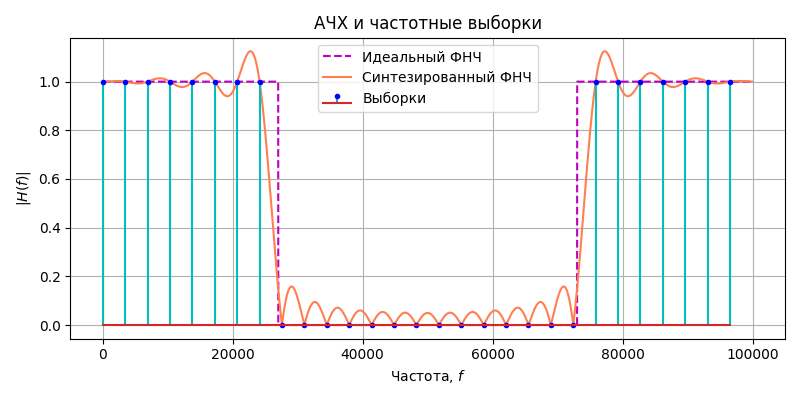

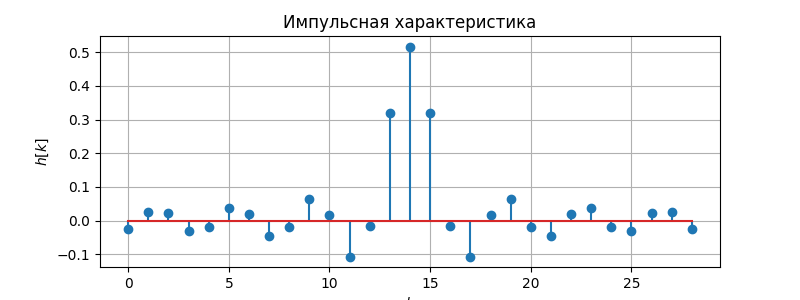

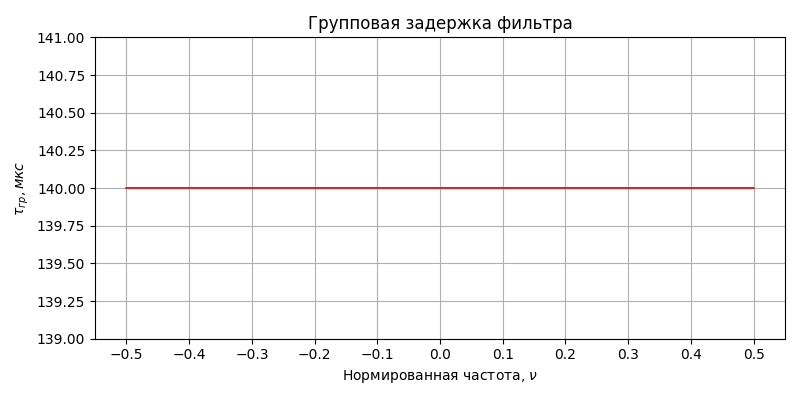

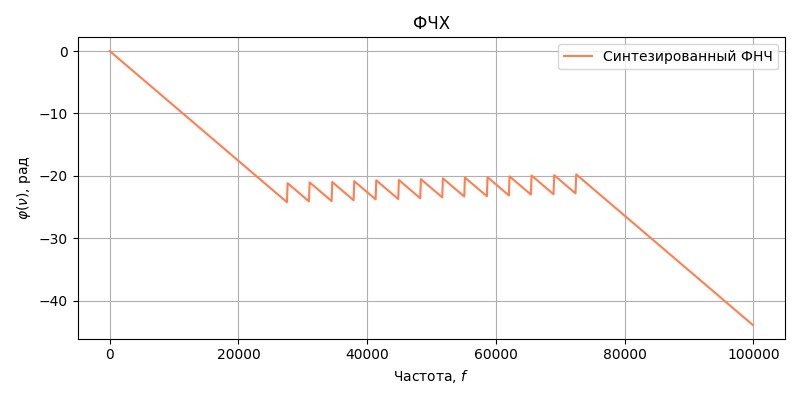

In [4]:
N=29 # число отсчетов h[k], нечетное
f_c = (f1+f2)/2

def ideal_lowpass(f, f_c, fs): # модифицировать эту функцию в задачах 1.2 и 1.3
    if 0 <= f <= f_c or fs-f_c <= f <=  fs:
        return 1.0 +0.0j
    else:
        return 0.0 +0.0j

H=np.zeros(N, dtype=complex)
for n in range(N):
    phase = 0
    # phase = -2 * np.pi * float(N-1)/2.0 * n / float(N)
    H[n]=ideal_lowpass(f=fs*n/N, f_c=f_c, fs=fs) * np.exp(1j*phase)

h=np.fft.ifft(H).real
h=np.roll(h, N//2) # сдвиг h[k] - попробовать добавить

w, h_resp = signal.freqz(h, worN=8192, fs=fs)
d1 = np.max(np.abs(np.abs(h_resp[w <= f1]) - 1))
d2 = np.max(np.abs(h_resp[w >= f2]))
print(f"delta1: {d1:.4f}, delta2: {d2:.4f}")

M=1024
H_dtft=np.fft.fft(h, M)
plt.close()
plots_sampling(h, H, H_dtft, fs, f_c, ideal_mag_resp = ideal_lowpass,
               phase_unwrap=True, set_of_plots=["АЧХ и частотные выборки", "Импульсная характеристика",
                                                                      "Групповая задержка фильтра", "ФЧХ"])


## Задача 1.2. Синтез ФНЧ по непрерывной АЧХ.

Синтезировать КИХ-фильтр 28 порядка ($N=29$) на основе идеального фильтра нижних частот с граничной частотой полосы пропускания $f_1$ и с граничной частотой полосы задерживания $f_2$ методом частотной выборки. Частоту дискретизации принять равной $f_s$. Частотную характеристику идеального фильтра в полосе перехода аппроксимировать линейной функцией так, чтобы характеристика была непрерывной.

а) Определить максимальные уровни пульсаций $\delta_1$ и $\delta_2$ в полосе пропускания и в полосе задерживания. Сравнить с результатом в задаче 1.1.

б) Изобразить на одном графике АЧХ фильтра и отсчеты ДПФ. 

в) Построить импульсную характеристику полученного КИХ-фильтра. Определить по виду импульсной характеристики, будет ли 
фильтр обладать постоянной фазовой и группой задержками.

г) Получить график для групповой задержки фильтра. Сравнить с выводом в пункте (в).

д) Определить частоту среза (по уровню $-3$ дБ) модельного и полученного фильтров. 

delta1: 0.1098, delta2: 0.1170
cutoff (-3db): 25970.46 hz


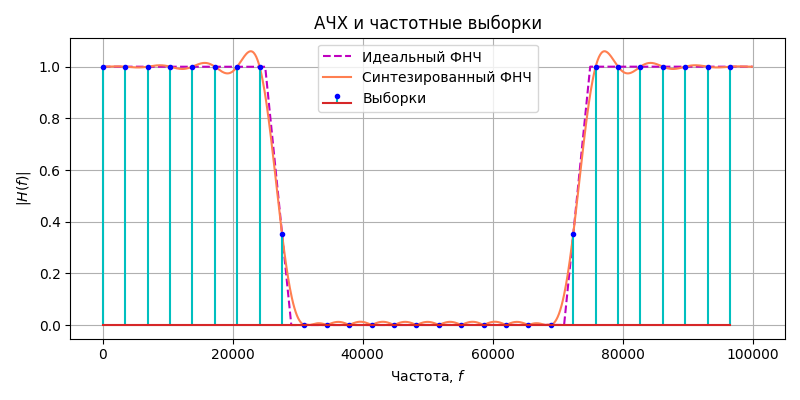

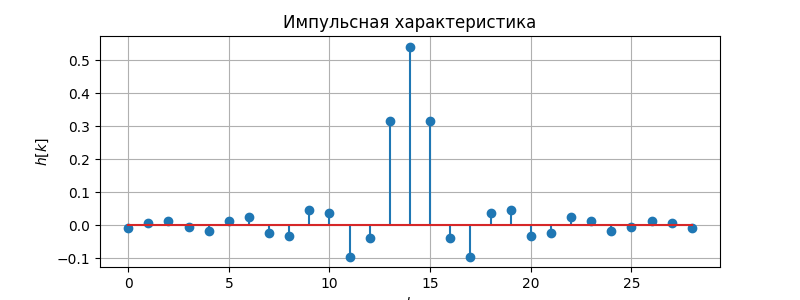

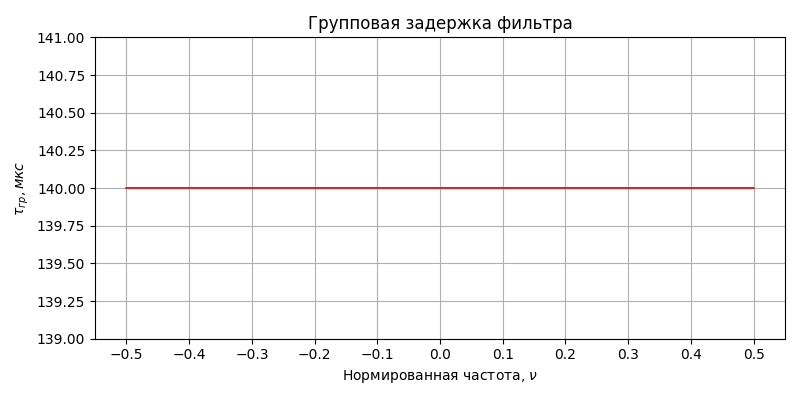

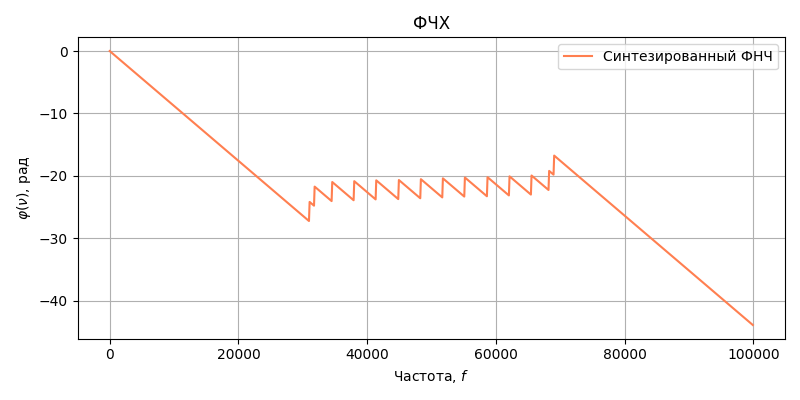

In [5]:
# модифицировать код из задачи 1.1.
N = 29
f_c = (f1 + f2) / 2

def linear_lowpass(f, f_c, fs):
    f_mod = f if f <= fs / 2 else fs - f
    if f_mod <= f1:
        return 1.0 + 0.0j
    if f_mod >= f2:
        return 0.0 + 0.0j
    return (f2 - f_mod) / (f2 - f1) + 0.0j

H = np.zeros(N, dtype=complex)
for n in range(N):
    H[n] = linear_lowpass(f=fs * n / N, f_c=f_c, fs=fs)

h = np.real(np.fft.ifft(H))
h = np.roll(h, N // 2)

w, h_resp = signal.freqz(h, worN=8192, fs=fs)
d1 = np.max(np.abs(np.abs(h_resp[w <= f1]) - 1))
d2 = np.max(np.abs(h_resp[w >= f2]))
print(f"delta1: {d1:.4f}, delta2: {d2:.4f}")

cutoff_idx = np.argmin(np.abs(20 * np.log10(np.abs(h_resp)) + 3))
print(f"cutoff (-3db): {w[cutoff_idx]:.2f} hz")

m_points = 1024
h_dtft = np.fft.fft(h, m_points)

plots_sampling(h, H, h_dtft, fs, f_c, ideal_mag_resp=linear_lowpass, phase_unwrap=True,
               set_of_plots=["АЧХ и частотные выборки", "Импульсная характеристика", "Групповая задержка фильтра", "ФЧХ"])


## Задача 1.3. Синтез фильтра с характеристикой «приподнятый косинус»

Синтезировать КИХ-фильтр 28 порядка ($N=29$) с частотой среза $f_c=(f_1+f_2)/2$  на основе фильтра приподнятого косинуса методом частотной выборки. Частоту дискретизации принять равной $f_s$. На интервале $[-f_s/2, f_s/2]$ частотная характеристика фильтра задается следующим образом 

$$H(f)=\left\{ \begin{matrix}
   1, & |f| < (1-\beta)f_c;\\
   \dfrac{1}{2}*\left( 1+\cos \left(\pi \dfrac{|f|-(1-\beta)f_c}{2\beta f_c} \right) \right), & (1-\beta) f_c \le |f| \le (1+\beta)f_c;  \\
   0,   &  |f| > (1+\beta)f_c. \\
\end{matrix} \right.$$

а) Подобрать такое $\beta$, чтобы модельный фильтр не выходил за максимально допустимые отклонения АЧХ в полосе пропускания и в полосе задерживания ($\delta_1$ и $\delta_2$). Изобразить полученную АЧХ фильтра.

б) Для синтезированного фильтра определить максимальные уровни пульсаций $\delta_1$ и $\delta_2$ в полосе пропускания и в полосе задерживания. Сравнить с результатами в задаче 1.1 и задаче 1.2.

в) Изобразить на одном графике АЧХ фильтра и отсчеты ДПФ. 

г) Построить импульсную характеристику полученного КИХ-фильтра. Определить по виду импульсной характеристики, будет ли 
фильтр обладать постоянной фазовой и группой задержками.

д) Получить график для групповой задержки фильтра. Сравнить с выводом в пункте (г).

е) Определить частоту среза (по уровню $-3$ дБ) полученного фильтра. Сравнить с задачей 1.2.


optimal beta: 0.0986
delta1: 0.1161, delta2: 0.0992
cutoff (-3db): 25903.32 hz


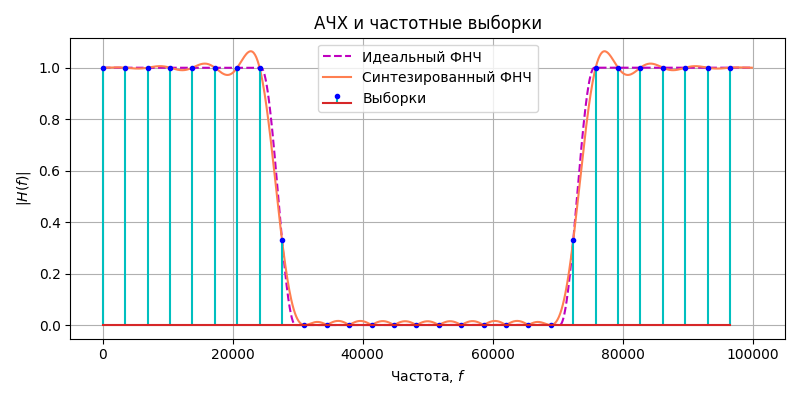

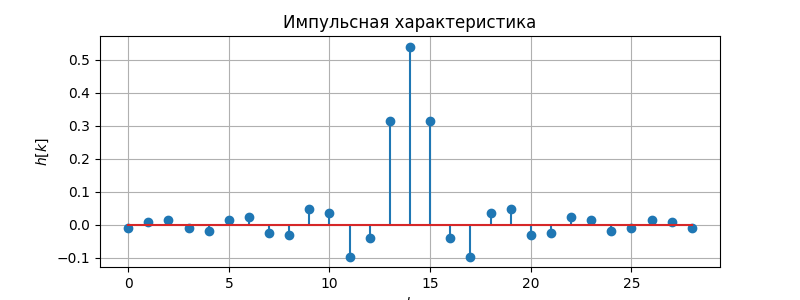

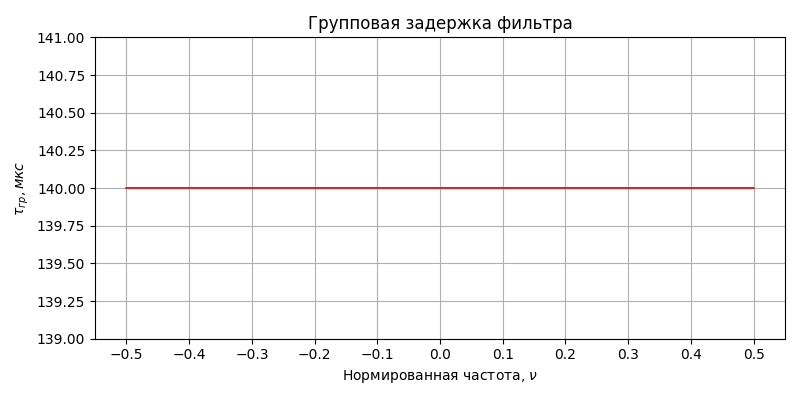

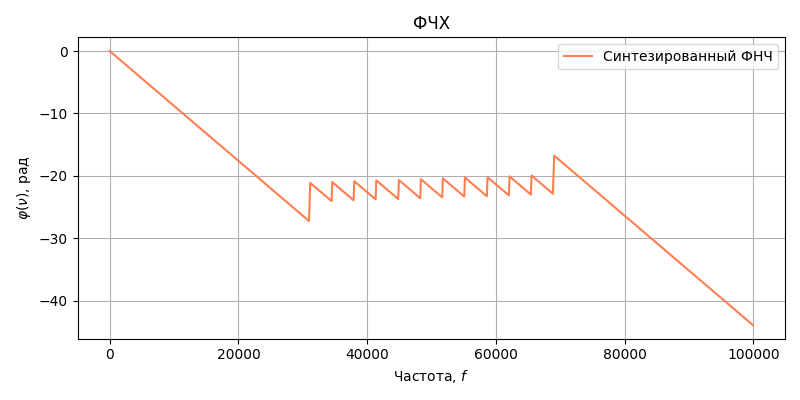

In [6]:
# модифицировать код из задачи 1.1.
N = 29
f_c = (f1 + f2) / 2

def rcos_lowpass(f, f_c, fs, beta):
    f_mod = f if f <= fs / 2 else fs - f
    edge1 = (1 - beta) * f_c
    edge2 = (1 + beta) * f_c
    if f_mod < edge1:
        return 1.0 + 0.0j
    if f_mod > edge2:
        return 0.0 + 0.0j
    return 0.5 * (1 + np.cos(np.pi * (f_mod - edge1) / (2 * beta * f_c))) + 0.0j

best_beta = None
best_h = None
best_h_freq = None
min_error = float('inf')

for b in np.linspace(0.01, 0.99, 200):
    h_f = np.zeros(N, dtype=complex)
    for n in range(N):
        h_f[n] = rcos_lowpass(f=fs * n / N, f_c=f_c, fs=fs, beta=b)

    h_tmp = np.real(np.fft.ifft(h_f))
    h_tmp = np.roll(h_tmp, N // 2)

    w, h_resp = signal.freqz(h_tmp, worN=8192, fs=fs)
    d1 = np.max(np.abs(np.abs(h_resp[w <= f1]) - 1))
    d2 = np.max(np.abs(h_resp[w >= f2]))

    error = max(d1 / delta1, d2 / delta2)
    if error < min_error:
        min_error = error
        best_beta = b
        best_h = h_tmp
        best_h_freq = h_f

print(f"optimal beta: {best_beta:.4f}")

w, h_resp = signal.freqz(best_h, worN=8192, fs=fs)
d1 = np.max(np.abs(np.abs(h_resp[w <= f1]) - 1))
d2 = np.max(np.abs(h_resp[w >= f2]))
print(f"delta1: {d1:.4f}, delta2: {d2:.4f}")

cutoff_idx = np.argmin(np.abs(20 * np.log10(np.abs(h_resp)) + 3))
print(f"cutoff (-3db): {w[cutoff_idx]:.2f} hz")

m_points = 1024
h_dtft = np.fft.fft(best_h, m_points)

plots_sampling(best_h, best_h_freq, h_dtft, fs, f_c,
               ideal_mag_resp=lambda f, f_c, fs: rcos_lowpass(f, f_c, fs, best_beta),
               phase_unwrap=True,
               set_of_plots=["АЧХ и частотные выборки", "Импульсная характеристика", "Групповая задержка фильтра", "ФЧХ"])


#  Модуль 2. Метод окон для синтеза КИХ-фильтров

### Задача 2.1. Сравнение АЧХ фильтров одного порядка 
Синтезировать КИХ-фильтры нижних частот c частотой среза $f_c$ при частоте дискретизации $f_s$ порядка $R=28$ ($N=29$) с использованием следующих окон:

* прямоугольное (окно Дирихле)
$$w[k]=\left\{ \begin{matrix}
   1,  \\
   0,  \\
\end{matrix}\begin{matrix}
   \ \ 0\le k\le N-1;  \\
   \left\{ k<0 \right\}\cup \left\{ k\ge N \right\}.  \\
\end{matrix} \right.$$

* окно Ханна 
$$w[k]=\left\{ \begin{matrix}
   0,5-0,5\cos \dfrac{2\pi k}{N-1}, & 0\le k\le N-1;  \\
   0, &\left\{ k<0 \right\}\cup \left\{ k\ge N \right\}. \\
\end{matrix} \right.$$

* окно Хэмминга
$$w[k]=\left\{ \begin{matrix}
   0,54-0,46\cos \dfrac{2\pi k}{N-1}, & 0\le k\le N-1;  \\
   0, &\left\{ k<0 \right\}\cup \left\{ k\ge N \right\}. \\
\end{matrix} \right.$$

* окно Блэкмана
$$w[k]=\left\{ \begin{matrix}
   0,42-0,5\cos \dfrac{2\pi k}{N-1}+0,08\cos \dfrac{4\pi k}{N-1}, & 0\le k\le N-1;  \\
   0, &\left\{ k<0 \right\}\cup \left\{ k\ge N \right\}. \\
\end{matrix} \right.$$


Построить графики оконной функции $w[k]$, импульсной характеристики КИХ-фильтра $h[k]$, АЧХ КИХ-фильтра(в линейном масштабе и в дБ). Определить по графикам максимальный уровень пульсаций по полосе задерживания в дБ. Заполнить таблицу.

In [7]:
# Заполните таблицу.
# Формат заполнения: ["Максимальный уровень пульсаций, дБ"]
data = {
    "Окно Дирихле": [" ", " "],
    "Окно Ханна":   [" ", " "],
    "Окно Хэмминга": [" ", " "],
    "Окно Блэкмана": [" ", " "],
}
pd.DataFrame(data, index=["Максимальный уровень пульсаций, дБ", "Ширина полосы перехода, кГц"])


,Окно Дирихле,Окно Ханна,Окно Хэмминга,Окно Блэкмана
"Максимальный уровень пульсаций, дБ",,,,
"Ширина полосы перехода, кГц",,,,


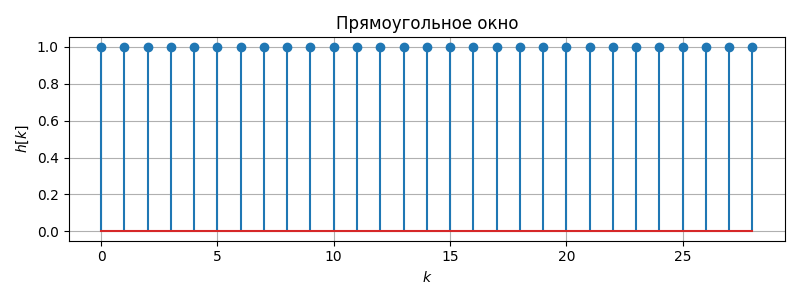

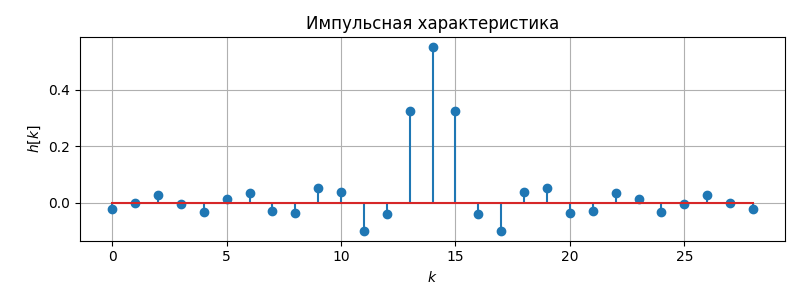

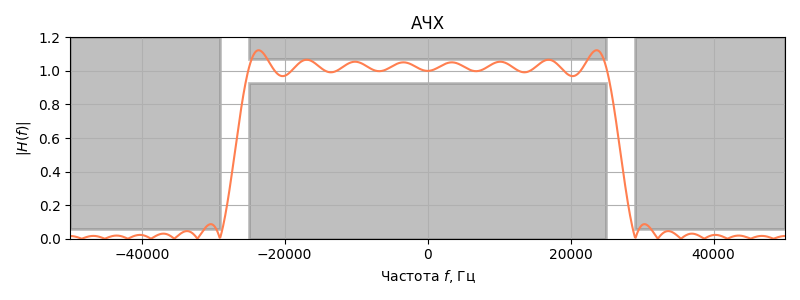

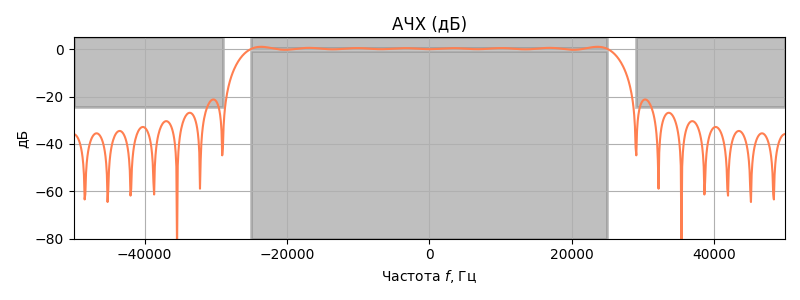

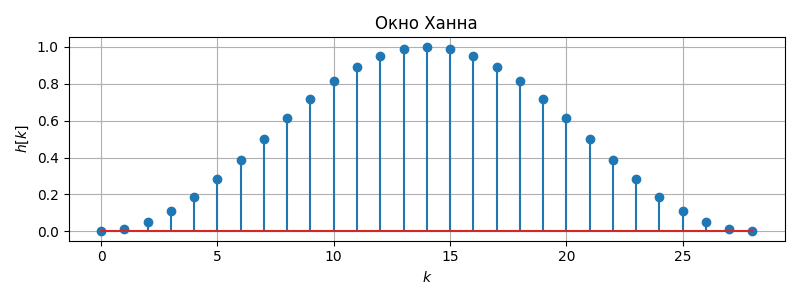

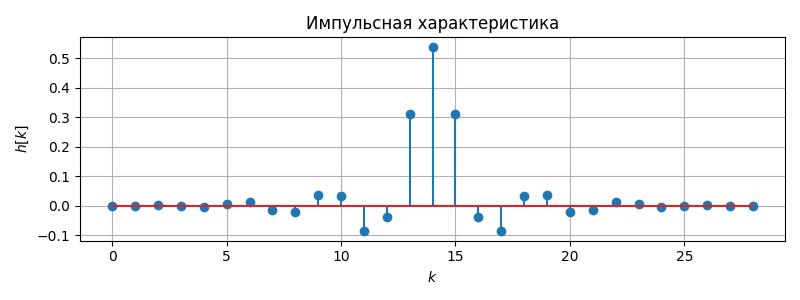

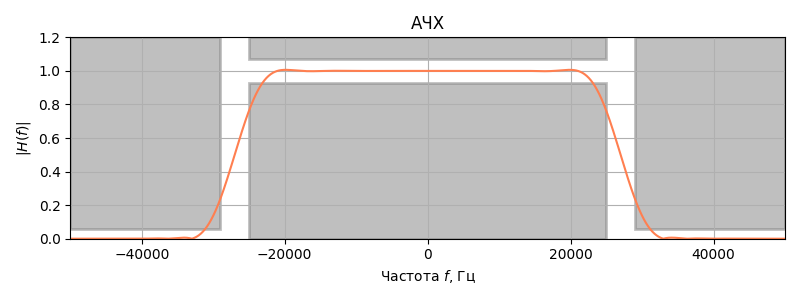

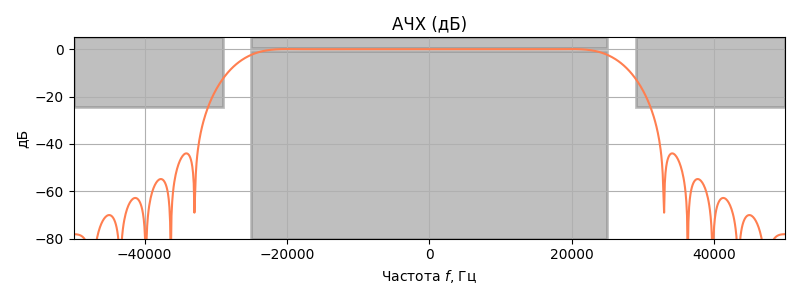

/tmp/ipykernel_104730/3249578882.py:137: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=[8, 3])


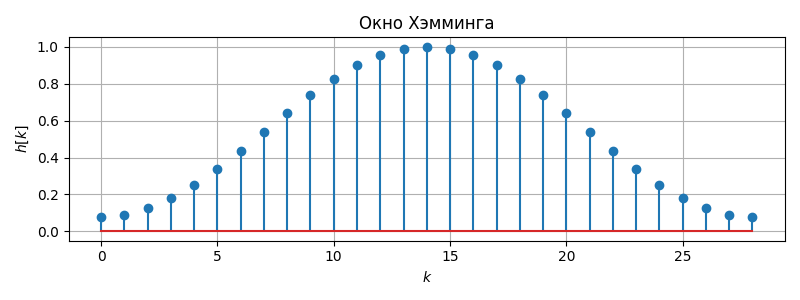

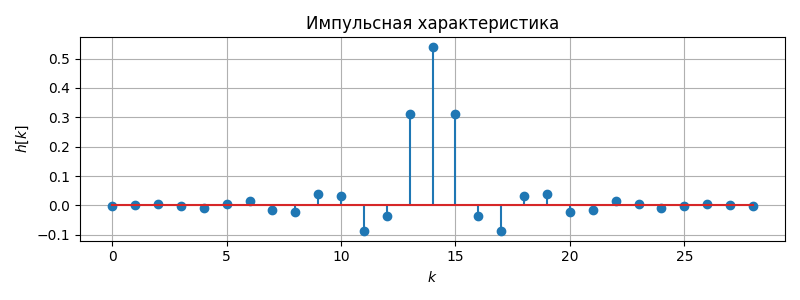

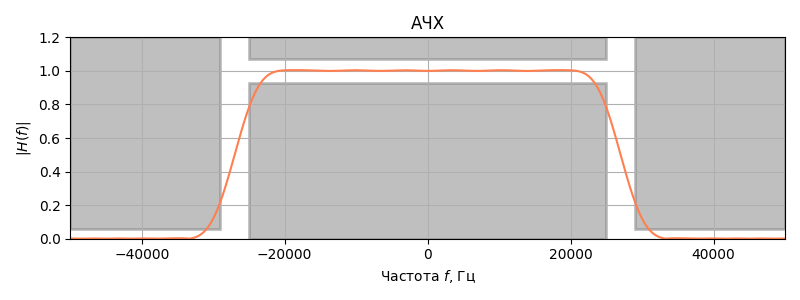

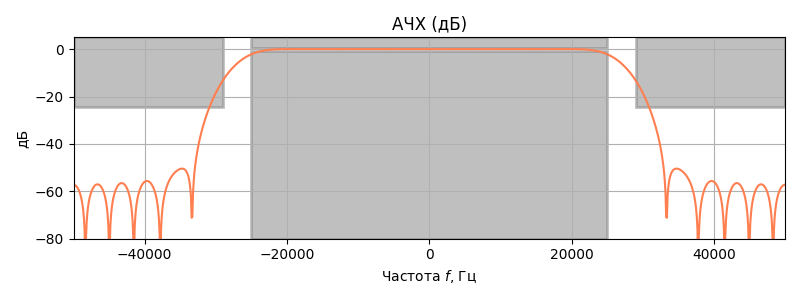

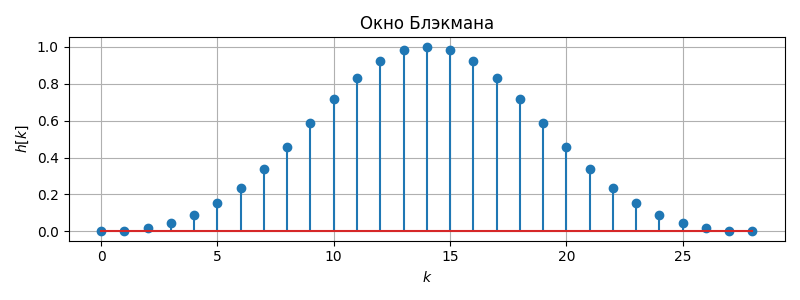

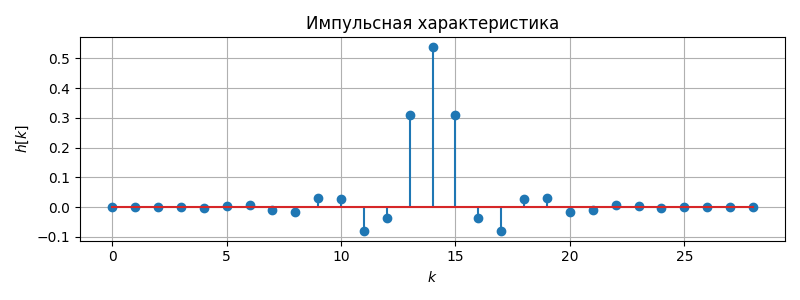

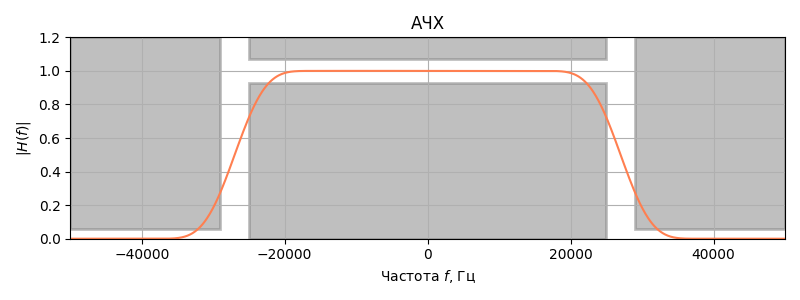

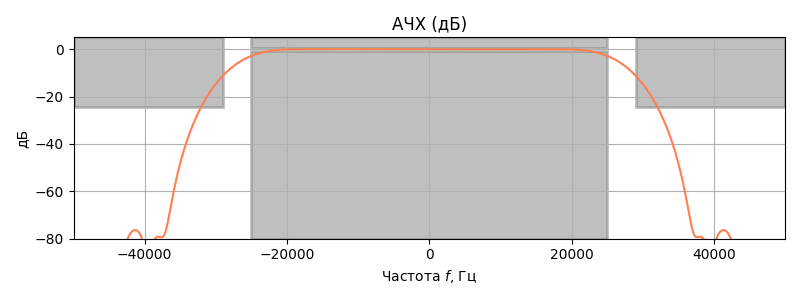

                                   Окно Дирихле Окно Ханна Окно Хэмминга  \
Максимальный уровень пульсаций, дБ       -21.23     -12.47        -13.15   
Ширина полосы перехода, кГц                2.06       2.75          2.70   

                                   Окно Блэкмана  
Максимальный уровень пульсаций, дБ        -11.16  
Ширина полосы перехода, кГц                 2.79  


In [8]:
cutoff = (f1 + f2) / 2
n_taps = 29
windows_map = {
    "boxcar": "Окно Дирихле",
    "hann": "Окно Ханна",
    "hamming": "Окно Хэмминга",
    "blackman": "Окно Блэкмана"
}

data = {}
for win_key, win_name in windows_map.items():
    h = signal.firwin(numtaps=n_taps, cutoff=cutoff, window=win_key, pass_zero='lowpass', fs=fs)
    w, h_resp = signal.freqz(h, worN=16384, fs=fs)
    h_db = 20 * np.log10(np.maximum(np.abs(h_resp), 1e-15))
    max_ripple_db = np.max(h_db[w >= f2])

    pass_idx = np.where(h_db <= -3)[0]
    stop_idx = np.where(h_db <= max_ripple_db + 3)[0]

    bw = 0
    if len(pass_idx) > 0 and len(stop_idx) > 0:
        bw = (w[stop_idx[0]] - w[pass_idx[0]]) / 1000

    data[win_name] = [f"{max_ripple_db:.2f}", f"{bw:.2f}"]
    plots_windowing(h, fs, f1, f2, delta1, delta2, win_key, set_of_plots=["Окно", "Импульсная характеристика", "АЧХ", "АЧХ (дБ)"])

df = pd.DataFrame(data, index=["Максимальный уровень пульсаций, дБ", "Ширина полосы перехода, кГц"])
print(df)


### Задача 2.2. Синтез ФНЧ с окном Хемминга. 

Синтезировать КИХ-фильтр нижних частот с окном Хемминга наименьшего порядка при заданных требованиях к АЧХ:
* частота дискретизации $f_s$,
* граничная частота полосы пропускания $f_1$,
* граничная частота полосы задерживания $f_2$,
* максимально допустимое отклонение АЧХ в полосе пропускания $\delta_1$,
* максимально допустимое отклонение АЧХ в полосе задерживания $\delta_2$.

Воспользоваться следующей итерационной процедурой [1]:

1) Оценить длину окна по формуле 

$$\hat{N}=\left[\dfrac{3,3 f_s}{\Delta f} \right], \;\;  \Delta f=f_2-f_1$$

2) Взвесить импульсную характеристику идеального фильтра c ФЧХ $\varphi(\theta)=- \dfrac{R}{2} \theta$ окном Хэмминга выбранной длины (``scipy.firwin``, $f_c=(f_1+f_2)/2$).

$$h[k]=\left\{ \begin{matrix}
   {{h}_{\text{ideal}}}[k]w[k],  \\
   0,  \\
\end{matrix}\begin{matrix}
   \ \ 0\le k\le N-1;  \\
   \left\{ k<0 \right\}\cup \left\{ k\ge N \right\}.  \\
\end{matrix} \right.$$

$$w[k]=\left\{ \begin{matrix}
   0,54-0,46\cos \dfrac{2\pi k}{N-1}, & 0\le k\le N-1;  \\
   0, &\left\{ k<0 \right\}\cup \left\{ k\ge N \right\}. \\
\end{matrix} \right.$$

3) Проверить выполнение требований к АЧХ фильтра. Если требования не выполняются, следует увеличить порядок фильтра $R$ (на некоторое целое число) и перейти на п. 2. Если требования выполняются, то нужно уменьшить порядок фильтра  $R$ и перейти на п. 2. Уменьшение и увеличение порядка производится до тех пор, пока не будет найден минимальный порядок , при котором выполняются требования к АЧХ и уменьшение порядка на единицу приводит к нарушению требований к фильтру. 

Проверку требований к АЧХ можно произвести по графику, используя
* backend notebook `%matplotlib notebook` (в Jupyter Notebook)
* `plt.xlim()` и `plt.ylim()` (в Google Colab или в Jupyter Notebook)

Приведите графики АЧХ КИХ-фильтра с начальным ($\hat{R}=\hat{N}-1$) и конечным $R_\min$ порядками в итерационной процедуре. 
______

[1] Солонина, А. И. Цифровая обработка сигналов в зеркале MATLAB : учебное пособие / А. И. Солонина .— Санкт-Петербург : БХВ-Петербург, 2021 .— 560 с. — (Учебная литература для вузов).

P.S. Есть в библиотеке МФТИ. 
______

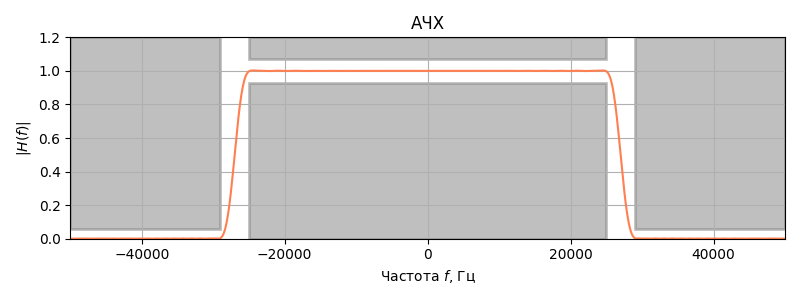

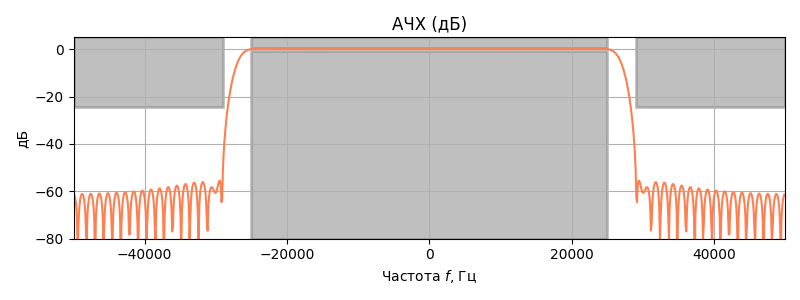

estimated n: 83, minimal n: 56


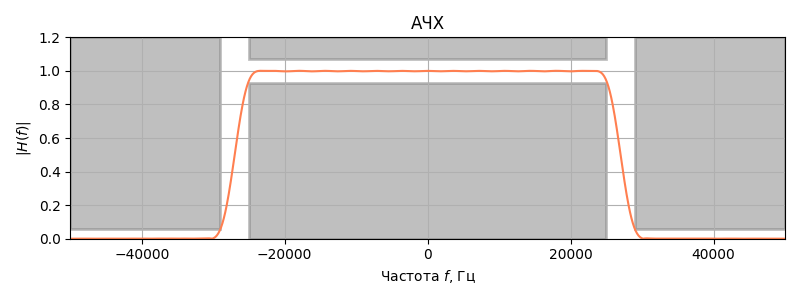

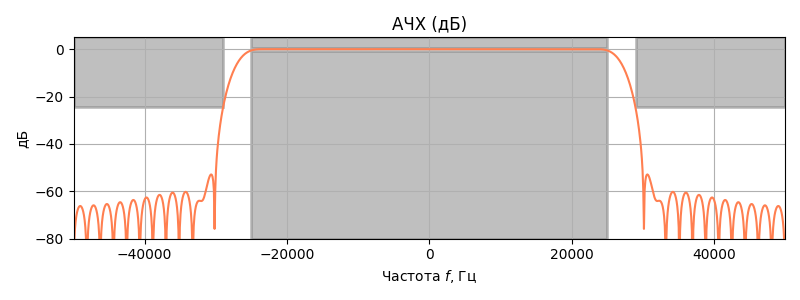

In [9]:
plt.close()
def check_reqs(h, fs, f1, f2, d1, d2):
    w, h_resp = signal.freqz(h, worN=16384, fs=fs)
    mag = np.abs(h_resp)
    max_d1 = np.max(np.abs(mag[w <= f1] - 1))
    max_d2 = np.max(mag[w >= f2])
    return max_d1 <= d1 and max_d2 <= d2

cutoff = (f1 + f2) / 2
n_est = int(np.ceil(3.3 * fs / (f2 - f1)))
h_est = signal.firwin(numtaps=n_est, cutoff=cutoff, window='hamming', pass_zero='lowpass', fs=fs)
plots_windowing(h_est, fs, f1, f2, delta1, delta2, 'hamming', set_of_plots=["АЧХ", "АЧХ (дБ)"])
n_min = n_est

while True:
    h = signal.firwin(numtaps=n_min, cutoff=cutoff, window='hamming', pass_zero='lowpass', fs=fs)
    if check_reqs(h, fs, f1, f2, delta1, delta2):
        while True:
            n_min -= 1
            h_test = signal.firwin(numtaps=n_min, cutoff=cutoff, window='hamming', pass_zero='lowpass', fs=fs)
            if not check_reqs(h_test, fs, f1, f2, delta1, delta2):
                n_min += 1
                break
        break
    n_min += 1

print(f"estimated n: {n_est}, minimal n: {n_min}")
h_min = signal.firwin(numtaps=n_min, cutoff=cutoff, window='hamming', pass_zero='lowpass', fs=fs)
plots_windowing(h_min, fs, f1, f2, delta1, delta2, 'hamming', set_of_plots=["АЧХ", "АЧХ (дБ)"])


## Задача 2.3. Синтез ФНЧ с окном Кайзера.

Синтезировать КИХ-фильтр нижних частот с окном Кайзера наименьшего порядка при заданных требованиях к АЧХ :
* частота дискретизации $f_s$,
* граничная частота полосы пропускания $f_1$,
* граничная частота полосы задерживания $f_2$,
* максимально допустимое отклонение АЧХ в полосе пропускания $\delta_1$,
* максимально допустимое отклонение АЧХ в полосе задерживания $\delta_2$.

Параметр $\beta$ и длину окна $N$ определить по эмпирическим формулам, приведенным в лекции, или с помощью функции `signal.kaiserord`. Привести график АЧХ получившегося фильтра, сравнить порядок с фильтром из задачи 2.2. 

kaiser estimated n: 30, minimal n: 33, beta: 1.2283


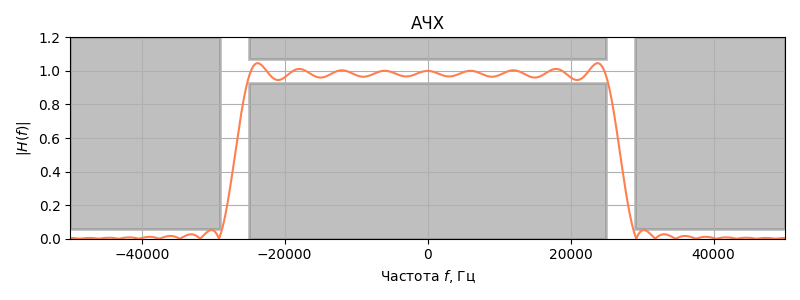

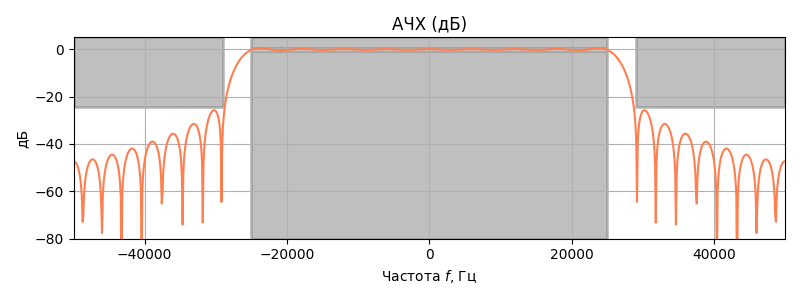

In [10]:
cutoff = (f1 + f2) / 2
attenuation = -20 * np.log10(min(delta1, delta2))
n_kaiser, beta = signal.kaiserord(ripple=attenuation, width=(f2 - f1) / (fs / 2))

n_min_kaiser = n_kaiser
while True:
    h = signal.firwin(numtaps=n_min_kaiser, cutoff=cutoff, window=('kaiser', beta), pass_zero='lowpass', fs=fs)
    if check_reqs(h, fs, f1, f2, delta1, delta2):
        while True:
            n_min_kaiser -= 1
            h_test = signal.firwin(numtaps=n_min_kaiser, cutoff=cutoff, window=('kaiser', beta), pass_zero='lowpass', fs=fs)
            if not check_reqs(h_test, fs, f1, f2, delta1, delta2):
                n_min_kaiser += 1
                break
        break
    n_min_kaiser += 1

print(f"kaiser estimated n: {n_kaiser}, minimal n: {n_min_kaiser}, beta: {beta:.4f}")
h_min_kaiser = signal.firwin(numtaps=n_min_kaiser, cutoff=cutoff, window=('kaiser', beta), pass_zero='lowpass', fs=fs)
plots_windowing(h_min_kaiser, fs, f1, f2, delta1, delta2, ('kaiser', beta), set_of_plots=["АЧХ", "АЧХ (дБ)"])


#  Модуль 3. Оптимизационные методы синтеза КИХ-фильтров

## Задача 3.1. Метод наименьших квадратов.

Синтезировать КИХ-фильтр методом наименьших квадратов наименьшего порядка при заданных требованиях к АЧХ :
* частота дискретизации $f_s$,
* граничная частота полосы пропускания $f_1$,
* граничная частота полосы задерживания $f_2$,
* максимально допустимое отклонение АЧХ в полосе пропускания $\delta_1$,
* максимально допустимое отклонение АЧХ в полосе задерживания $\delta_2$.

Использовать следующую итерационную процедуру:

1) Выбрать начальный порядок фильтра $R$ (например, можно взять результат решения задачи 2.3).

2) Используя функцию `scipy.signal.firls`, синтезировать КИХ-фильтр порядка $R$ методом наименьших квадратов.

3) Проверить выполнение требований к АЧХ фильтра. Если требования не выпоняются, следует увеличить порядок фильтра $R$ (на некоторое целое число) и перейти на п. 2. Если требования выполняются, то нужно уменьшить порядок фильтра  $R$ и перейти на п. 2. Уменьшение и увеличение порядка производится до тех пор, пока не будет найден минимальный порядок , при котором выполняются требования к АЧХ и уменьшение порядка на единицу приводит к нарушению требований к фильтру. 

Приведите график АЧХ КИХ-фильтра минимального порядка $R_\min$ в итерационной процедуре. 

ls minimal n: 39


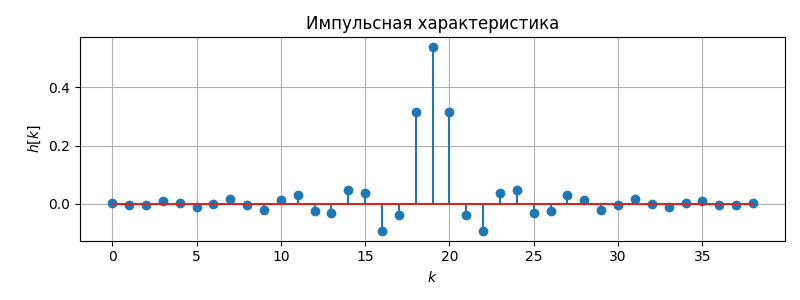

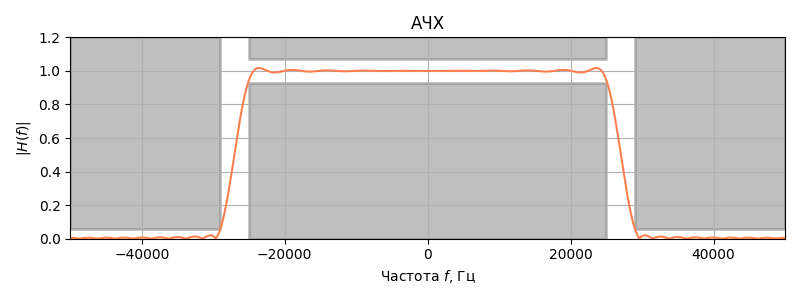

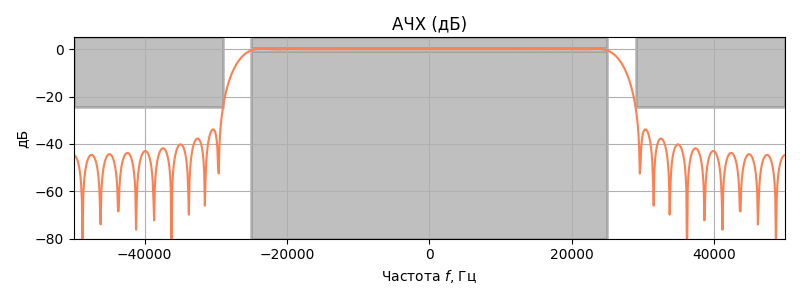

In [11]:
bands = np.array([0, f1, f2, fs / 2])
desired = np.array([1, 1, 0, 0])
weights = np.array([1 / delta1, 1 / delta2])

n_min_ls = 29
while True:
    h = signal.firls(numtaps=n_min_ls, bands=bands, desired=desired, weight=weights, fs=fs)
    if check_reqs(h, fs, f1, f2, delta1, delta2):
        while True:
            n_min_ls -= 2
            h_test = signal.firls(numtaps=n_min_ls, bands=bands, desired=desired, weight=weights, fs=fs)
            if not check_reqs(h_test, fs, f1, f2, delta1, delta2):
                n_min_ls += 2
                break
        break
    n_min_ls += 2

print(f"ls minimal n: {n_min_ls}")
h_ls = signal.firls(numtaps=n_min_ls, bands=bands, desired=desired, weight=weights, fs=fs)
plots_optimization(h_ls, fs, f1, f2, delta1, delta2, set_of_plots=["Импульсная характеристика", "АЧХ", "АЧХ (дБ)"])


## Задача 3.2. Метод равномерной чебышевской аппроксимации.

Синтезировать КИХ-фильтр методом равномерной чебышевской аппроксимации наименьшего порядка при заданных требованиях к АЧХ :
* частота дискретизации $f_s$,
* граничная частота полосы пропускания $f_1$,
* граничная частота полосы задерживания $f_2$,
* максимально допустимое отклонение АЧХ в полосе пропускания $\delta_1$,
* максимально допустимое отклонение АЧХ в полосе задерживания $\delta_2$.

Использовать следующую итерационную процедуру:

1) Выбрать начальный порядок фильтра $R$ (например, можно взять результат решения задачи 2.3).

2) Используя функцию `scipy.signal.remez`, синтезировать КИХ-фильтр порядка $R$ методом наименьших квадратов.

3) Проверить выполнение требований к АЧХ фильтра. Если требования не выпоняются, следует увеличить порядок фильтра $R$ (на некоторое целое число) и перейти на п. 2. Если требования выполняются, то нужно уменьшить порядок фильтра  $R$ и перейти на п. 2. Уменьшение и увеличение порядка производится до тех пор, пока не будет найден минимальный порядок , при котором выполняются требования к АЧХ и уменьшение порядка на единицу приводит к нарушению требований к фильтру. 

Приведите график АЧХ КИХ-фильтра минимального порядка $R_\min$ в итерационной процедуре. 

remez minimal n: 25


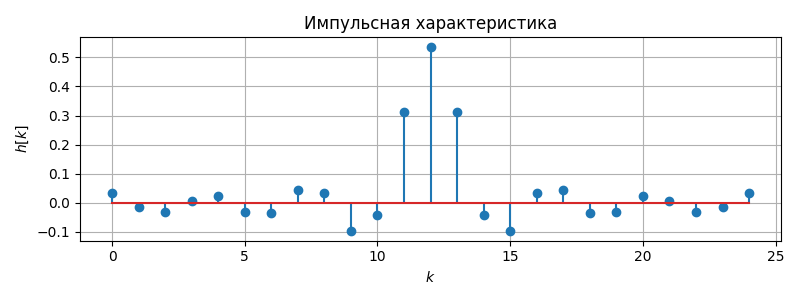

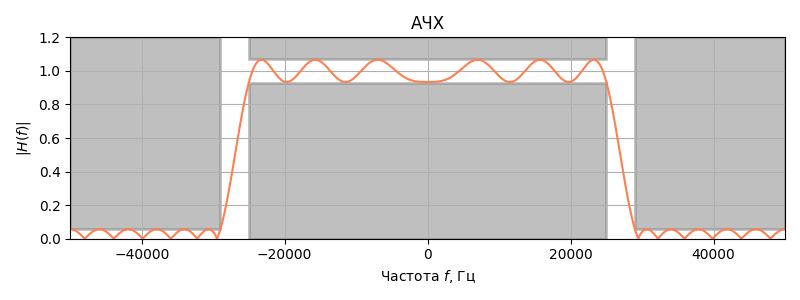

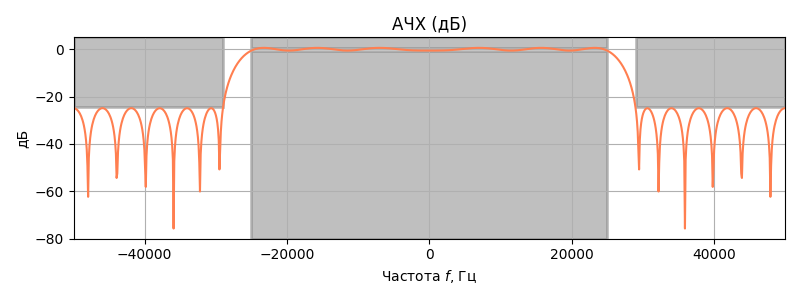

In [12]:
bands = np.array([0, f1, f2, fs / 2])
desired = np.array([1, 0])
weights = np.array([1 / delta1, 1 / delta2])

n_min_remez = 29
while True:
    try:
        h = signal.remez(numtaps=n_min_remez, bands=bands, desired=desired, weight=weights, fs=fs)
        met = check_reqs(h, fs, f1, f2, delta1, delta2)
    except ValueError:
        met = False

    if met:
        while True:
            n_min_remez -= 1
            try:
                h_test = signal.remez(numtaps=n_min_remez, bands=bands, desired=desired, weight=weights, fs=fs)
                if not check_reqs(h_test, fs, f1, f2, delta1, delta2):
                    n_min_remez += 1
                    break
            except ValueError:
                n_min_remez += 1
                break
        break
    n_min_remez += 1

print(f"remez minimal n: {n_min_remez}")
h_remez = signal.remez(numtaps=n_min_remez, bands=bands, desired=desired, weight=weights, fs=fs)
plots_optimization(h_remez, fs, f1, f2, delta1, delta2, set_of_plots=["Импульсная характеристика", "АЧХ", "АЧХ (дБ)"])


## Задача 3.3. Сравнение результатов.

Сравнить минимальные порядки КИХ-фильтров, которые получились в задачах 2.2, 2.3, 3.1 и 3.2. Заполнить таблицу. Определить, будут ли выполняться требование из этих задач для фильтра минимального из получившихся порядков, построенного методом частотной выборки (как в задаче 1.2).


In [13]:
plot_data = {
    "Оконный метод (окно Хэмминга)": [n_min - 1, n_min],
    "Оконный метод (окно Кайзера)": [n_min_kaiser - 1, n_min_kaiser],
    "Метод наименьших квадратов":[n_min_ls - 1, n_min_ls],
    "Метод равномерной чебышевской аппроксимации":[n_min_remez - 1, n_min_remez]
}

df_summary = pd.DataFrame(data=plot_data, index=["r_min", "n_min"]).T
print(df_summary)

n_test = min(n_min, n_min_kaiser, n_min_ls, n_min_remez)
h_test_freq = np.zeros(n_test, dtype=complex)
for n in range(n_test):
    h_test_freq[n] = linear_lowpass(f=fs * n / n_test, f_c=f_c, fs=fs)
h_test_res = np.real(np.fft.ifft(h_test_freq))
h_test_res = np.roll(h_test_res, n_test // 2)

is_met = check_reqs(h_test_res, fs, f1, f2, delta1, delta2)
print(f"frequency sampling method with n={n_test} meets reqs: {is_met}")


                                             r_min  n_min
Оконный метод (окно Хэмминга)                   55     56
Оконный метод (окно Кайзера)                    32     33
Метод наименьших квадратов                      38     39
Метод равномерной чебышевской аппроксимации     24     25
frequency sampling method with n=25 meets reqs: False


#  Модуль 4. Фильтрация сигнала.

## Задача 4.1. Фильтрация АМ-сигнала, полученного с помощью цифрового осциллографа.
Установить в управляющей программе цифрового осциллографа следующие параметры. 
* Число выборок 1000, режим "Нормально".
* Пробник "х1".
* Частота дискретизации 100 кГц (Время/дел 1mS). 
* Синхронизация "Вкл." и "Авто".
* Генератор: Генератор: режим "АМ/ЧМ", вид "~", диапазон "10K", размах колебания 4В. Частоту генератора выбрать в соответствии с вариантом из таблицы. Установить частоту несущей $f_0$ в соответствии с вариантом задания. 
* Модуляция генератора (меню "Настройки"): режим "АМ", коэффициент модуляции 70%, модулирующая частота 1кГц. 

Выполнить следующую последовательность действий. 
1) Пронаблюдать сигнал с амплитудной модуляцией. 
2) Записать выборки в текстовый файл.
3) Синтезировать КИХ-фильтр одним из рассмотренных методов так, чтобы его АЧХ удовлетворяла условиям задачи. При этом не обязательно использовать фильтр наименьшего возможного порядка. 
4) Провести фильтрацию сигнала. Сравнить сигналы и спектры сигналов до и после фильтрации.
5) Определить групповую задержку фильтра в мс. 
6) Синтезировать БИХ-фильтр Баттерворта, удовлетворяющий тем же требованиям. Сравнить результаты фильтрации сигналов КИХ-фильтром и БИХ-фильтром во временной области.

In [14]:
# использовать примеры кода из материалов занятия
# Основные функции работы с файлами данных осциллографа
def oscilloscope_file_read(file, const_level=0):
    f = open(file)
    str1 = f.read().split('\n')
    f.closed

    figsize=[8, 4]

    # dt
    val, unit = str1[1].replace(',', '.').split(' ')[3:5]
    val=float(val)
    if unit=='uS':
        val*=1e-6
    elif unit=='nS':
        val*=1e-9
    elif unit=='mS':
        val*=1e-3
    fs = int(1.0 / val)

    #Voltage step
    val, unit = str1[2].replace(',', '.').split(' ')[3:5]
    dv=float(val)
    if unit=='mV':
        dv*=1e-3


    # Zero level
    zero_level= int(str1[3].split(' ')[3])
    str_num = len(str1)
    signal_lev = np.empty(shape=(str_num-8), dtype=float)
    for k, u in enumerate(range(7, str_num-1, 1)):
        data = str1[u].split()
        signal_lev[k]=(int(data[1])-zero_level)*dv-const_level
    return fs, signal_lev


fir group delay: 0.120 ms


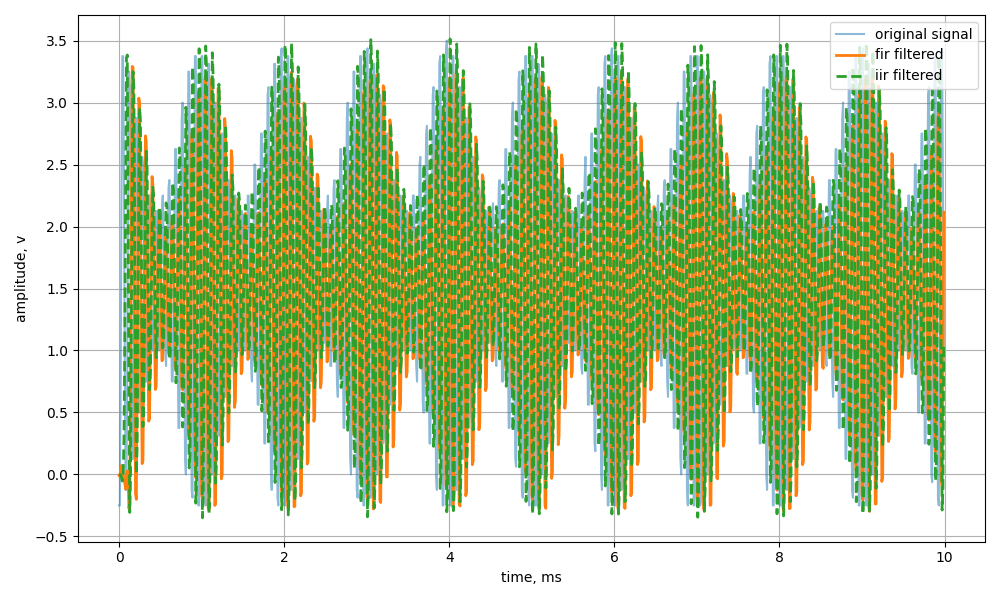

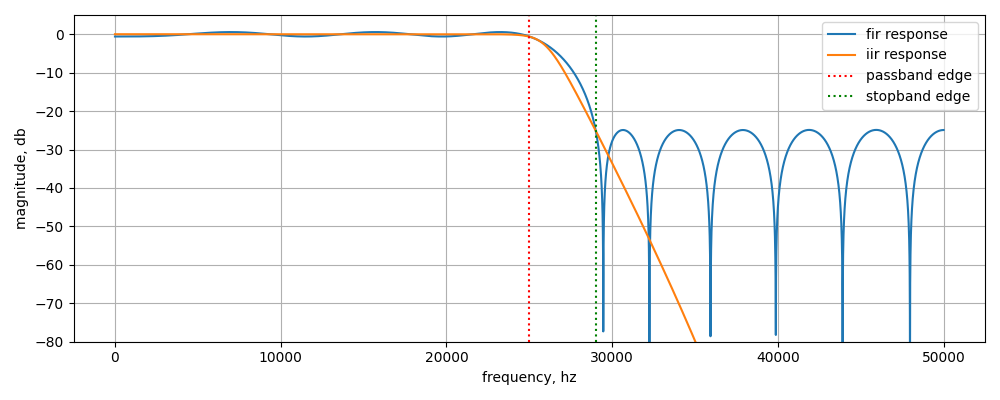

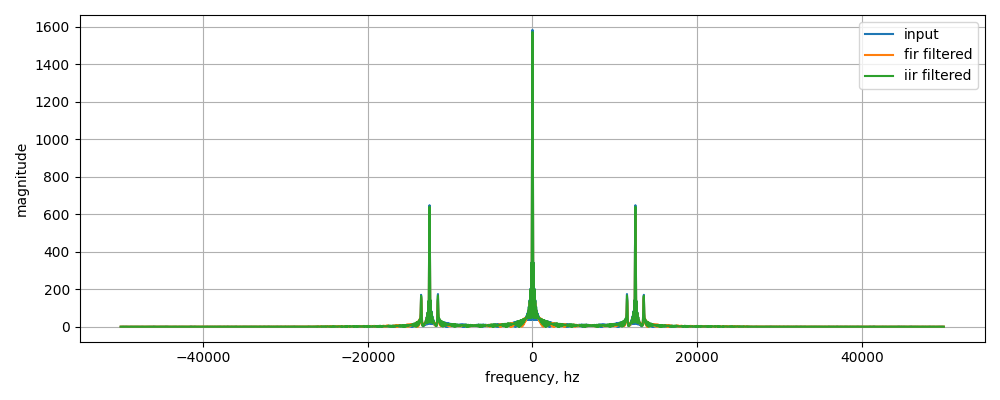

In [15]:
plt.close()
def generate_mock_am(fs, f0, length=1000):
    t = np.arange(length) / fs
    f_mod = 1000
    return (1 + 0.7 * np.cos(2 * np.pi * f_mod * t)) * np.cos(2 * np.pi * f0 *1.5 * t)

fs_file, sig = oscilloscope_file_read("Data/vian/4.1.txt", const_level=0)

h_fir = signal.remez(numtaps=n_min_remez, bands=bands, desired=desired, weight=weights, fs=fs)
sig_fir = signal.lfilter(h_fir, [1.0], sig)

group_delay_fir = (len(h_fir) - 1) / 2 / fs * 1000
print(f"fir group delay: {group_delay_fir:.3f} ms")

n_butt, wn_butt = signal.buttord(wp=f1, ws=f2, gpass=-20*np.log10(1-delta1), gstop=-20*np.log10(delta2), fs=fs)
b_butt, a_butt = signal.butter(N=n_butt, Wn=wn_butt, btype='low', fs=fs)
sig_iir = signal.lfilter(b_butt, a_butt, sig)

t = np.arange(len(sig)) / fs * 1000

plt.figure(figsize=[10, 6])
plt.plot(t, sig, label='original signal', alpha=0.5)
plt.plot(t, sig_fir, label='fir filtered', linewidth=2)
plt.plot(t, sig_iir, label='iir filtered', linewidth=2, linestyle='--')
plt.xlabel('time, ms')
plt.ylabel('amplitude, v')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

f_freq, h_fir_freq = signal.freqz(h_fir, worN=8192, fs=fs)
f_freq, h_iir_freq = signal.freqz(b_butt, a_butt, worN=8192, fs=fs)

plt.figure(figsize=[10, 4])
plt.plot(f_freq, 20 * np.log10(np.maximum(np.abs(h_fir_freq), 1e-15)), label='fir response')
plt.plot(f_freq, 20 * np.log10(np.maximum(np.abs(h_iir_freq), 1e-15)), label='iir response')
plt.axvline(f1, color='red', linestyle=':', label='passband edge')
plt.axvline(f2, color='green', linestyle=':', label='stopband edge')
plt.ylim([-80, 5])
plt.xlabel('frequency, hz')
plt.ylabel('magnitude, db')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

dtft_m = 2048
nu = -0.5 + np.arange(dtft_m)/dtft_m
f =  nu * fs_file

plt.figure(figsize=[10, 4])
plt.plot(f, np.abs(np.fft.fftshift(np.fft.fft(sig, dtft_m))), label='input')
plt.plot(f, np.abs(np.fft.fftshift(np.fft.fft(sig_fir, dtft_m))), label='fir filtered')
plt.plot(f, np.abs(np.fft.fftshift(np.fft.fft(sig_iir, dtft_m))), label='iir filtered')
plt.xlabel('frequency, hz')
plt.ylabel('magnitude')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
